<a href="https://colab.research.google.com/github/M4rck0/Procesamiento_Clasificacion_Datos/blob/main/Tarea_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%%capture
!pip install ultralytics

In [3]:
# Librerías
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Modelo: YOLOv8

In [4]:
modelo = YOLO("yolov8n.pt")

In [5]:
imagen = cv2.imread('tarea_5.jpeg')

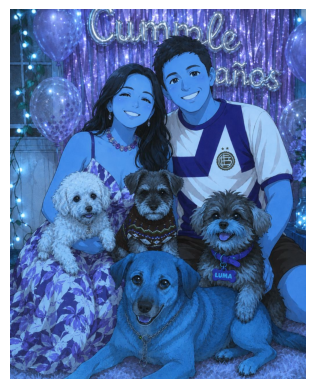

In [6]:
plt.figure()
plt.imshow(imagen)
plt.axis("off")
plt.show()

In [7]:
resultados = modelo.predict(source='tarea_5.jpeg', conf=0.20, save=False)


image 1/1 /content/tarea_5.jpeg: 640x512 2 persons, 2 dogs, 3 teddy bears, 437.5ms
Speed: 22.9ms preprocess, 437.5ms inference, 38.0ms postprocess per image at shape (1, 3, 640, 512)


In [8]:
resultado = resultados[0]

In [9]:
clases_modelo = modelo.names

print("Clases que puede detectar el modelo:")
print(clases_modelo)

Clases que puede detectar el modelo:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'key

In [11]:
# Filtrar detecciones
clases_interes = ["person", "dog"]

detecciones = []
imagen_detectada = imagen.copy()

for box in resultado.boxes:

    # Coordenadas de la caja
    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

    # Confianza de la detección
    confianza = float(box.conf[0].cpu().numpy())

    # Clase detectada
    clase_id = int(box.cls[0].cpu().numpy())
    clase_nombre = clases_modelo[clase_id]

    # Filtrar solo personas y perros
    if clase_nombre not in clases_interes:
        continue

    # Calcular centro de la caja
    centro_x = int((x1 + x2) / 2)
    centro_y = int((y1 + y2) / 2)

    # Guardar información
    detecciones.append({
        "clase": clase_nombre,
        "confianza": confianza,
        "x1": int(x1),
        "y1": int(y1),
        "x2": int(x2),
        "y2": int(y2),
        "centro_x": centro_x,
        "centro_y": centro_y
    })

    # Dibujar caja
    if clase_nombre == "person":
        color = (255, 0, 0)   # rojo en RGB
        etiqueta = "Persona"
    else:
        color = (0, 255, 0)   # verde en RGB
        etiqueta = "Perro"

    cv2.rectangle(
        imagen_detectada,
        (int(x1), int(y1)),
        (int(x2), int(y2)),
        color,
        3
    )

    # Dibujar centro
    cv2.circle(
        imagen_detectada,
        (centro_x, centro_y),
        7,
        color,
        -1
    )

    # Texto de la etiqueta
    texto = f"{etiqueta}: {confianza:.2f}"

    cv2.putText(
        imagen_detectada,
        texto,
        (int(x1), int(y1) - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        color,
        2
    )

In [12]:
# Tabla detecciones
df_detecciones = pd.DataFrame(detecciones)

print("Detecciones encontradas:")
display(df_detecciones)

# Conteo por clase
conteo = df_detecciones["clase"].value_counts()

print("\nConteo de objetos detectados:")
print(conteo)

Detecciones encontradas:


,clase,confianza,x1,y1,x2,y2,centro_x,centro_y
0,dog,0.884639,173,835,925,1279,549,1057
1,person,0.706730,104,187,561,752,333,469
2,person,0.668181,488,90,985,973,737,531
3,dog,0.226449,371,554,609,879,490,716



Conteo de objetos detectados:
clase
dog       2
person    2
Name: count, dtype: int64


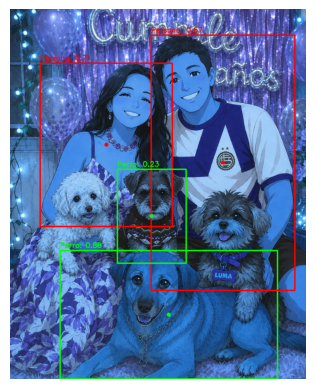

In [14]:
# Imagen con detecciones
plt.figure()
plt.imshow(imagen_detectada)
plt.axis("off")
plt.show()